In [83]:
import torch
import pandas as pd
import numpy as np
import os

from data.data_utils import preprocess_features

from models.rnn_models import LSTM, GRU, MultiChannelLSTM
from models.transformer import Transformer
from models.tcn import TCNModel


In [84]:
# === BASE EXPERIMENT CONFIG (low, PV, 24h, TE) ===

base_config = {
    "past_hours": 24,
    "future_hours": 24,
    "use_pv": True,
    "use_hist_weather": False,
    "use_forecast": False,
    "use_ideal_nwp": False,
    "use_time_encoding": True,
    "model_complexity": "low",
    "model_params": {
        "d_model": 32,
        "hidden_dim": 16,
        "num_heads": 2,
        "num_layers": 1,
        "dropout": 0.1,
        "tcn_channels": [16, 32],
        "kernel_size": 3,
    }
}


In [85]:
df_raw = pd.read_csv("data/Project1140.csv")
df_raw["Datetime"] = pd.to_datetime(df_raw["date"])


In [86]:
df_clean, hist_feats, fcst_feats, sh, sf, st, no_hist_power = \
    preprocess_features(df_raw.copy(), base_config)

print("Hist feats:", hist_feats)
print("Fcst feats:", fcst_feats)
print("Rows:", len(df_clean))


hist_dim = len(hist_feats)
fcst_dim = len(fcst_feats) if fcst_feats else 0

print("hist_dim =", hist_dim)
print("fcst_dim =", fcst_dim)

mp = base_config.copy()

mp["future_hours"] = base_config["future_hours"]
mp["past_hours"]   = base_config["past_hours"]
mp["use_forecast"] = base_config.get("use_forecast", False)
mp["use_time_encoding"] = base_config.get("use_time_encoding", True)
mp["te_dim"]       = base_config.get("te_dim",8)

print(mp)


Hist feats: ['Capacity_Factor_hist', 'month_cos', 'month_sin', 'hour_cos', 'hour_sin', 'daypos_cos', 'daypos_sin', 'hourpos_sin', 'hourpos_cos']
Fcst feats: []
Rows: 144145
hist_dim = 9
fcst_dim = 0
{'past_hours': 24, 'future_hours': 24, 'use_pv': True, 'use_hist_weather': False, 'use_forecast': False, 'use_ideal_nwp': False, 'use_time_encoding': True, 'model_complexity': 'low', 'model_params': {'d_model': 32, 'hidden_dim': 16, 'num_heads': 2, 'num_layers': 1, 'dropout': 0.1, 'tcn_channels': [16, 32], 'kernel_size': 3}, 'te_dim': 8}


In [87]:
def build_model(model_name, hist_dim, fcst_dim, config):
    mp = config["model_params"].copy()
    mp["past_hours"] = config["past_hours"]
    mp["future_hours"] = config["future_hours"]
    mp["use_forecast"] = config.get("use_forecast", False)
    mp["use_time_encoding"] = config.get("use_time_encoding", False)

    if model_name == "LSTM":
        return LSTM(hist_dim, fcst_dim, mp)

    elif model_name == "GRU":
        return GRU(hist_dim, fcst_dim, mp)

    elif model_name == "Transformer":
        return Transformer(hist_dim, fcst_dim, mp)

    elif model_name == "TCN":
        return TCNModel(hist_dim, fcst_dim, mp)

    elif model_name == "MultiChannelLSTM":
        return MultiChannelLSTM(hist_dim, fcst_dim, mp)

    else:
        raise ValueError(f"Unknown model type: {model_name}")


In [88]:
def load_checkpoint(model, path):
    checkpoint = torch.load(path, map_location="cpu")
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model


In [89]:
model_paths = {
    "LSTM": "/Users/jacobfernandez/Desktop/Research/FA2025/SolarPrediction/pt/LSTM/best_model_LSTM_low_PV_24h_TE.pt",
    "GRU": "/Users/jacobfernandez/Desktop/Research/FA2025/SolarPrediction/pt/GRU/best_model_GRU_low_PV_24h_TE.pt",
    "Transformer": "/Users/jacobfernandez/Desktop/Research/FA2025/SolarPrediction/pt/Transformer/best_model_Transformer_low_PV_24h_TE.pt",
    "TCN": "/Users/jacobfernandez/Desktop/Research/FA2025/SolarPrediction/pt/TCN/best_model_TCN_low_PV_24h_TE.pt",
    # "MultiChannelLSTM": "pt/MultiChannelLSTM/best_model_MultiChannelLSTM_low_PV_24h_TE.pt",
}


In [90]:
loaded_models = {}

for model_name, path in model_paths.items():
    print(f"\n=== Loading {model_name} ===")

    model = build_model(model_name, hist_dim, fcst_dim, base_config)
    model = load_checkpoint(model, path)

    loaded_models[model_name] = model
    print(f"{model_name} loaded successfully.")



=== Loading LSTM ===
LSTM loaded successfully.

=== Loading GRU ===
GRU loaded successfully.

=== Loading Transformer ===
Transformer loaded successfully.

=== Loading TCN ===
TCN loaded successfully.


/Users/jacobfernandez/Desktop/Research/FA2025/SolarPrediction/venv/lib/python3.13/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


In [91]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def sliding_48h_forecast(
    model,
    df_clean,
    hist_feats,
    fcst_feats,
    scaler_target,
    config,
    start_idx=0  # index of first sliding forecast
):
    """
    Generates a 48-hour visualization consisting of:
      • GT from t=0 → t=48h (288 points @ 10-min = 48*6)
      • 24 forecast curves (each 24h long, starting at hour offsets 0..23)

    model          → trained PyTorch model (already .eval())
    df_clean       → preprocessed DF from preprocess_features()
    hist_feats     → same list as during training
    fcst_feats     → same list as during training
    scaler_target  → target scaler
    config         → full config dict (past_hours, future_hours, etc.)
    start_idx      → sample index to slide over

    NOTE: past_hours = 24h → 144 steps
          future_hours = 24h → 144 steps
          48h window = 288 steps
    """

    model.eval()

    past_steps   = config["past_hours"] * 6
    future_steps = config["future_hours"] * 6
    
    # The sliding window will need GT for 48 hours:
    total_required_steps = past_steps + future_steps + (23 * 6)  # sliding start offsets

    # Ensure dataset is long enough
    assert len(df_clean) > start_idx + total_required_steps, \
        "Not enough data to perform sliding inference."

    # ------------------------------------------
    # Extract 48-hour ground truth (288 points)
    # ------------------------------------------
    gt_start = start_idx + past_steps
    gt_end   = gt_start + 48 * 6   # 48h horizon

    gt_48h_scaled = df_clean.iloc[gt_start:gt_end]["Capacity Factor"].values.reshape(-1, 1)
    gt_48h = scaler_target.inverse_transform(gt_48h_scaled).flatten()

    plt.figure(figsize=(18, 9))
    plt.plot(gt_48h, label="Ground Truth (48h)", linewidth=3, color="black")

    # ------------------------------------------
    # LOOP: Generate 24 predictions
    # ------------------------------------------
    for offset in range(0, 24):  # 0..23 hours
        step_shift = offset * 6  # convert hours→10min steps

        # Index where THIS forecast starts
        i = start_idx + past_steps + step_shift

        # Build historical window
        hist_data = df_clean.iloc[i - past_steps : i]
        Xh = hist_data[hist_feats].values.astype(np.float32).reshape(1, past_steps, -1)

        # Build future forecast inputs (if model uses forecast weather)
        if len(fcst_feats) > 0:
            fcst_data = df_clean.iloc[i : i + future_steps]
            Xf = fcst_data[fcst_feats].values.astype(np.float32).reshape(1, future_steps, -1)
        else:
            Xf = None

        # PyTorch tensors
        xh_t = torch.tensor(Xh, dtype=torch.float32)
        xf_t = torch.tensor(Xf, dtype=torch.float32) if Xf is not None else None

        # Model prediction
        with torch.no_grad():
            if xf_t is not None:
                pred_scaled = model(xh_t, xf_t).numpy().reshape(-1, 1)
            else:
                pred_scaled = model(xh_t).numpy().reshape(-1, 1)

        # Unscale
        pred = scaler_target.inverse_transform(pred_scaled).flatten()

        # RMSE over THIS forecast range
        gt_slice = gt_48h[step_shift : step_shift + future_steps]
        rmse = np.sqrt(np.mean((pred - gt_slice) ** 2))

        # Plot shifted into the 48h window
        t0 = step_shift
        t1 = step_shift + future_steps
        plt.plot(
            np.arange(t0, t1),
            pred,
            alpha=0.4,
            linewidth=2,
            label=f"+{offset}h Forecast (RMSE={rmse:.2f})"
        )

    plt.title("Sliding 24h Forecasts Over 48 Hours")
    plt.xlabel("Time Steps (10-min intervals, 288 = 48h)")
    plt.ylabel("Capacity Factor (%)")
    plt.grid(True, alpha=0.25)
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()


In [ ]:
def sliding_48h_forecast_with_individual_plots(
    model,
    df_clean,
    hist_feats,
    fcst_feats,
    config,
    midnight_index=None,model_string= None
):
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_squared_error
    import torch
    from models.tcn import TCNModel
    import pandas as pd

    # ==========================================================
    # 0) Locate midnight rows
    # ==========================================================
    if "Datetime" not in df_clean.columns:
        raise ValueError("df_clean must contain 'Datetime' column")

    df_midnight = df_clean[df_clean["Datetime"].dt.hour == 0]
    midnight_indices = df_midnight.index.tolist()

    if midnight_index is None:
        midnight_index = np.random.choice(len(midnight_indices))

    start_idx = midnight_indices[midnight_index]

    print(f"[INFO] Midnight sample #{midnight_index} → df index {start_idx}")
    print(f"[INFO] Timestamp = {df_clean.loc[start_idx, 'Datetime']}")

    # ==========================================================
    # Window sizes
    # ==========================================================
    hist_steps = config["past_hours"] * 6
    fut_steps  = config["future_hours"] * 6

    # ==========================================================
    # 1) Detect target
    # ==========================================================
    target_col = [c for c in df_clean if "cap" in c.lower()][0]
    y_full_48h = df_clean[target_col].iloc[start_idx : start_idx + 288].values

    preds_24 = []
    is_tcn = isinstance(model, TCNModel)

    # ==========================================================
    # 2) Build 48h datetime axis for plotting
    # ==========================================================
    dt0 = df_clean.loc[start_idx, "Datetime"]
    times_48h = [dt0 + pd.Timedelta(minutes=10 * i) for i in range(288)]

    # format labels (string HH:MM)
    time_labels_48h = [t.strftime("%H:%M") for t in times_48h]

    # ==========================================================
    # 3) Sliding prediction windows
    # ==========================================================
    for h in range(24):
        idx = start_idx + h * 6

        X_h = df_clean[hist_feats].iloc[idx - hist_steps : idx].values
        X_f = df_clean[fcst_feats].iloc[idx : idx + fut_steps].values

        if is_tcn:
            X_h_tensor = torch.tensor(X_h, dtype=torch.float32).T.unsqueeze(0)
            X_f_tensor = torch.tensor(X_f, dtype=torch.float32).T.unsqueeze(0)
        else:
            X_h_tensor = torch.tensor(X_h, dtype=torch.float32).unsqueeze(0)
            X_f_tensor = torch.tensor(X_f, dtype=torch.float32).unsqueeze(0)

        with torch.no_grad():
            pred = model(X_h_tensor, X_f_tensor).cpu().numpy().reshape(-1)

        preds_24.append(np.clip(pred, 0, None))

    # ==========================================================
    # 4) Combined sliding plot with HH:MM axis
    # ==========================================================
    plt.figure(figsize=(18, 8))

    plt.plot(
        times_48h, y_full_48h,
        color="black", linewidth=2, marker="o", markersize=2,
        label="Ground Truth (48h)"
    )

    for h in range(24):
        offset = h * 6
        pred = preds_24[h]
        rmse = np.sqrt(mean_squared_error(y_full_48h[offset:offset+144], pred))

        time_segment = times_48h[offset : offset + 144]

        plt.plot(
            time_segment,
            pred,
            linewidth=1.2,
            marker="o", markersize=2,
            label=f"+{h}h Forecast (RMSE={rmse:.2f})",
        )

    # clean tick formatting
    plt.xticks(times_48h[::6], time_labels_48h[::6], rotation=45)  # show 1 tick/hour

    plt.legend(ncol=3, fontsize=8)
    plt.grid(alpha=0.3)
    plt.title(f"Sliding 24h Forecasts Over 48h with {model_string} (Starting at Midnight)")
    plt.ylabel("Capacity Factor")
    plt.tight_layout()
    plt.show()

    # ==========================================================
    # 5) Individual 24h forecast plots
    # ==========================================================
    for h in range(24):

        plt.figure(figsize=(10, 4))

        offset = h * 6
        pred = preds_24[h]
        gt = y_full_48h[offset:offset+144]
        rmse = np.sqrt(mean_squared_error(gt, pred))

        # time axis for this segment
        times_24h = times_48h[offset : offset + 144]
        labels_24h = [t.strftime("%H:%M") for t in times_24h]

        plt.plot(times_24h, gt, linewidth=3.5, marker="o", markersize=3.5, label="Ground Truth")
        plt.plot(times_24h, pred, linewidth=2, marker="o", markersize=2,
                 label=f"Prediction +{h}h  (RMSE={rmse:.2f})")

        # x-axis formatting
        plt.xticks(times_24h[::6], labels_24h[::6], rotation=45)  # show 1 tick/hour

        plt.grid(alpha=0.3)
        plt.legend()
        plt.title(f"24h Forecast Starting +{h} Hours (Midnight #{midnight_index})")
        plt.ylabel("Capacity Factor")
        plt.tight_layout()
        plt.show()


936

[INFO] Midnight sample #923 → df index 127301
[INFO] Timestamp = 2022-06-03 00:50:00


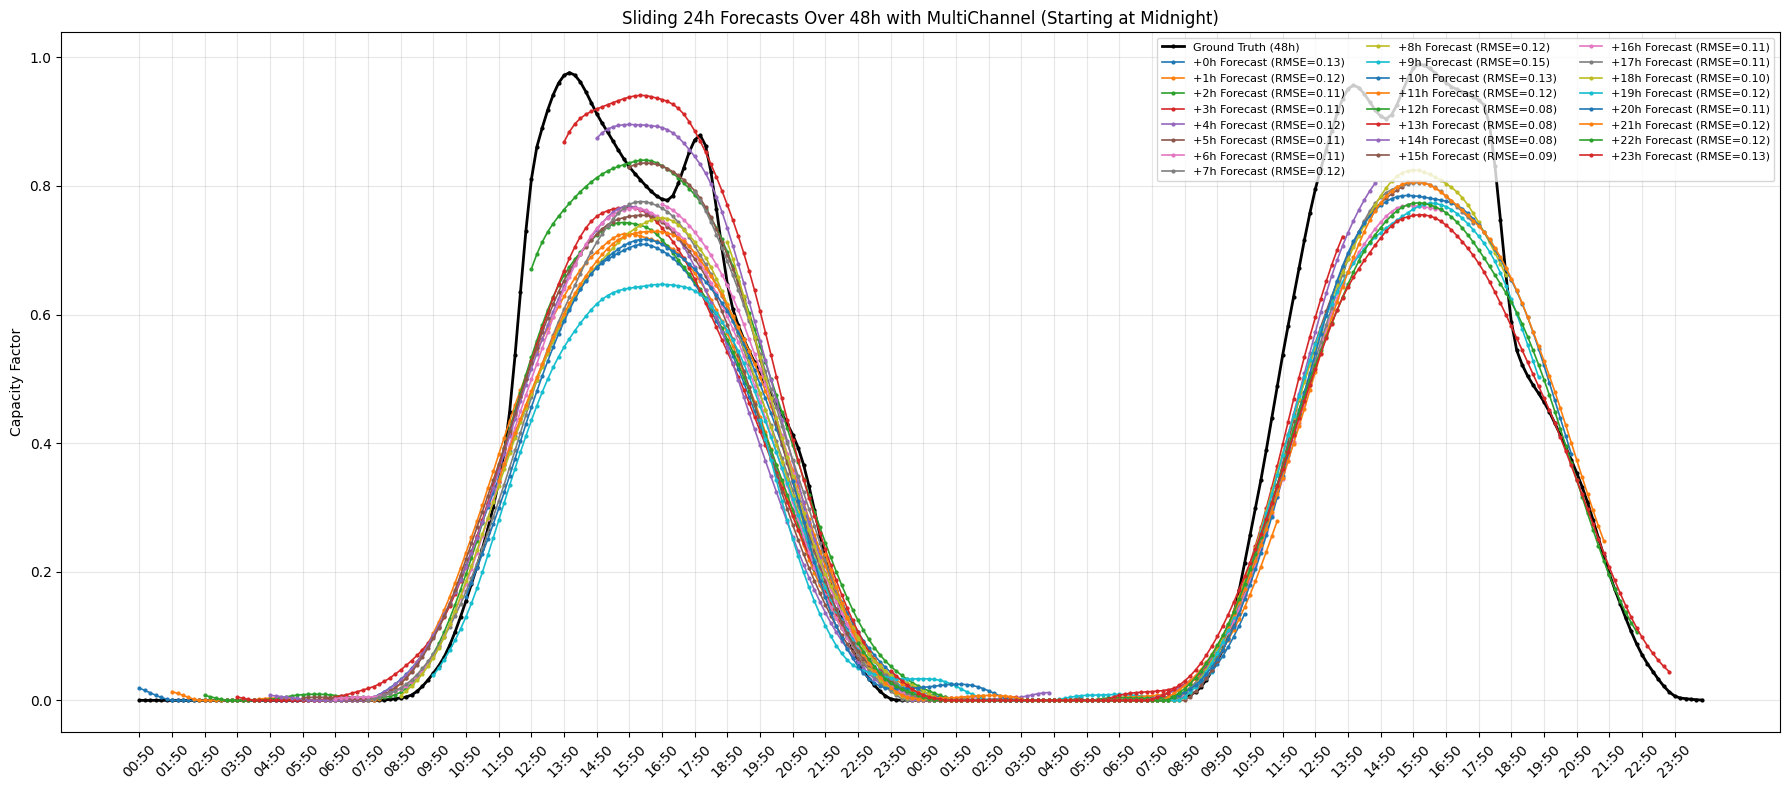

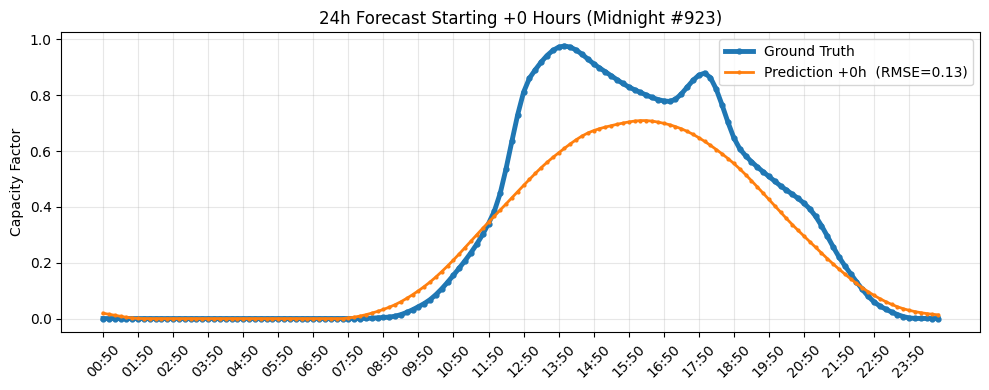

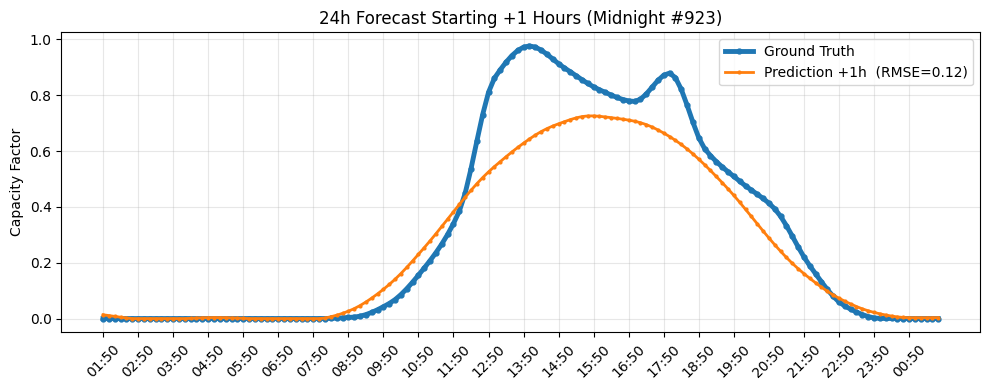

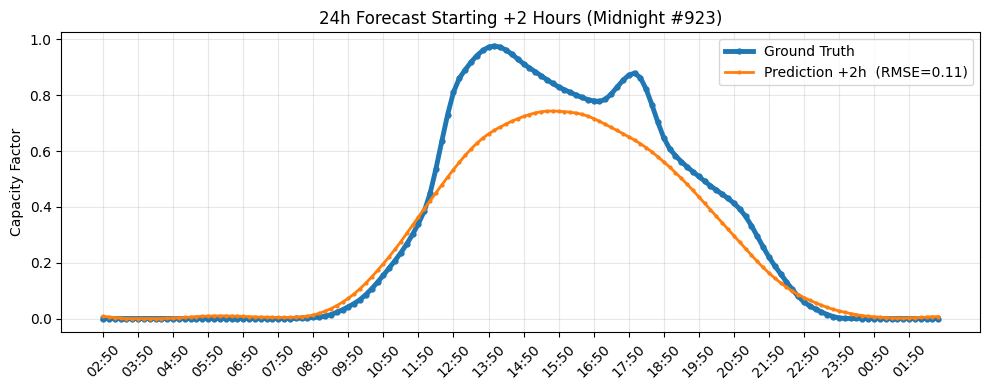

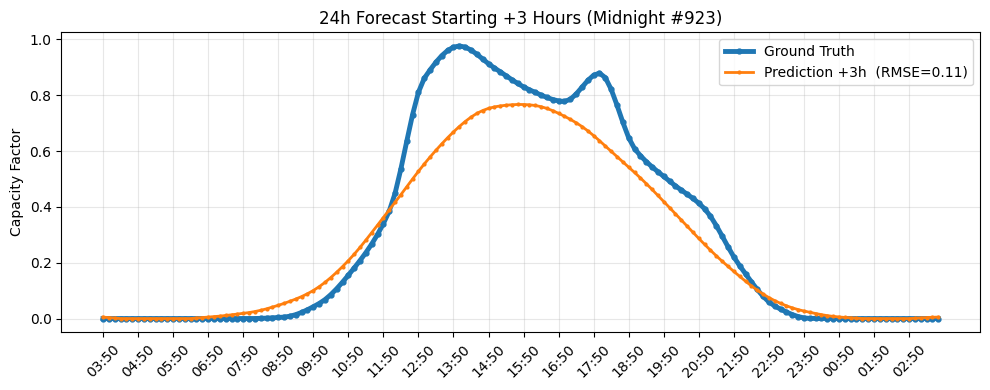

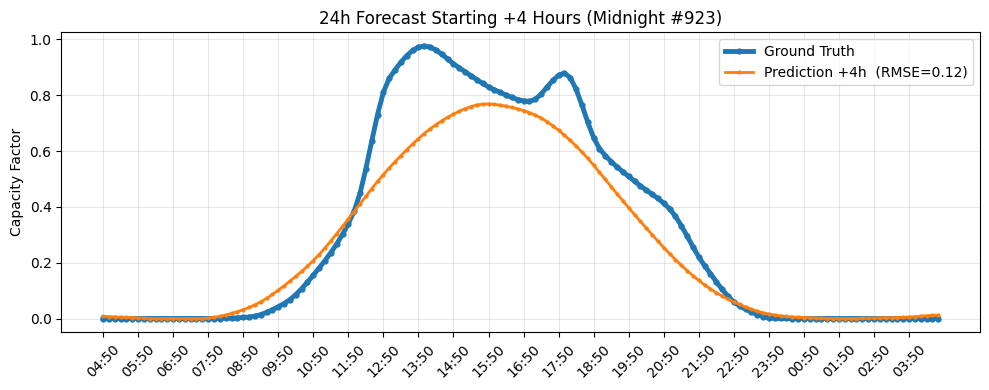

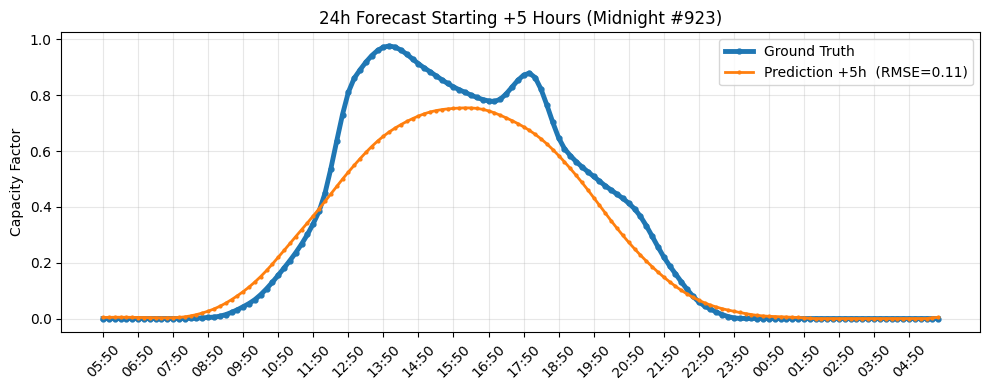

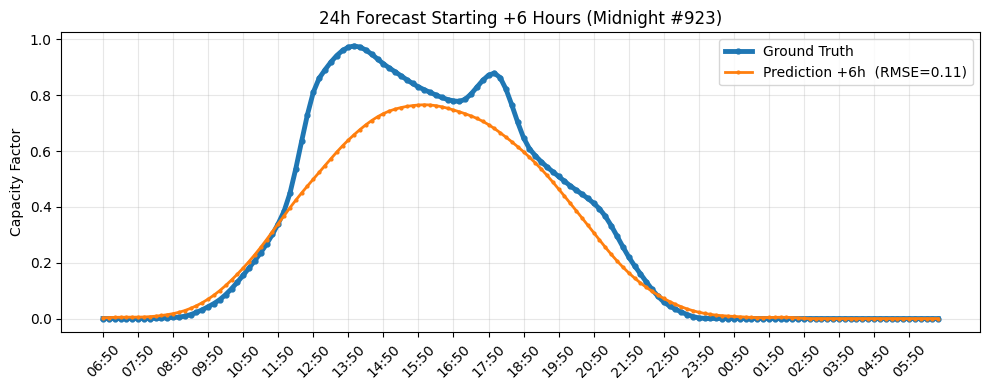

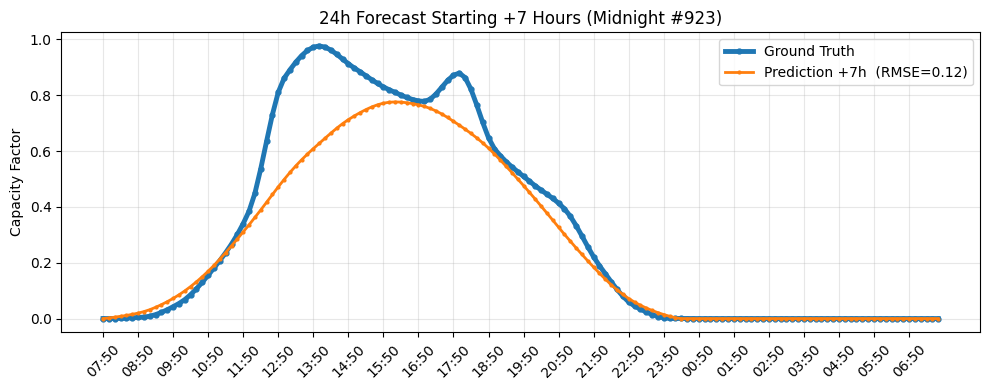

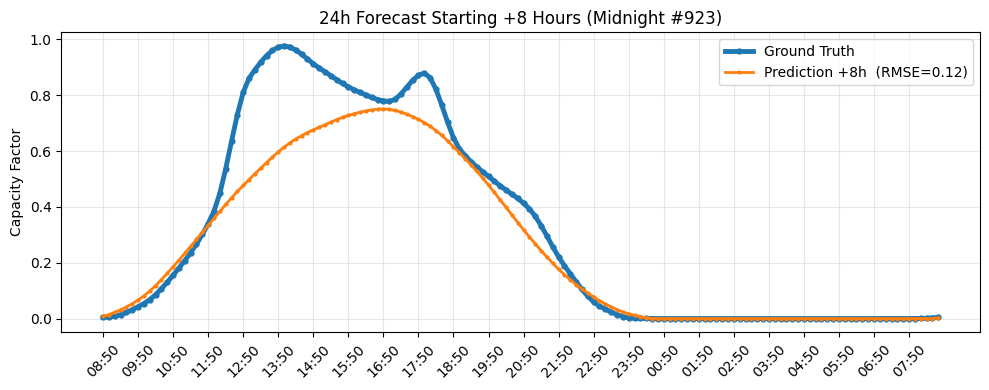

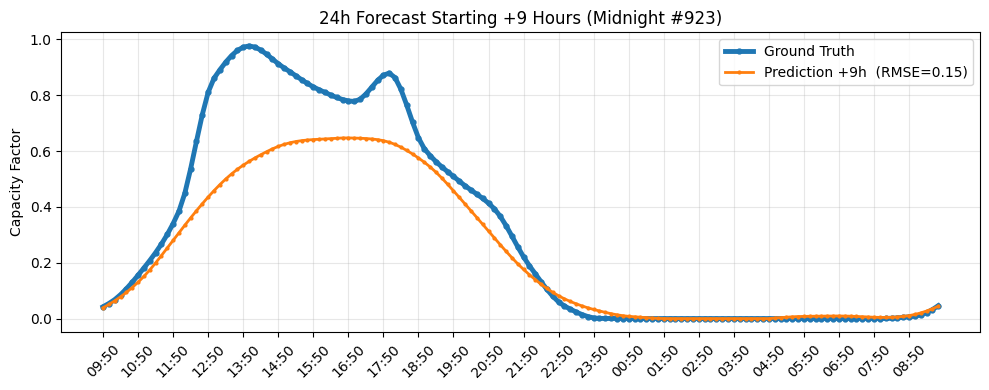

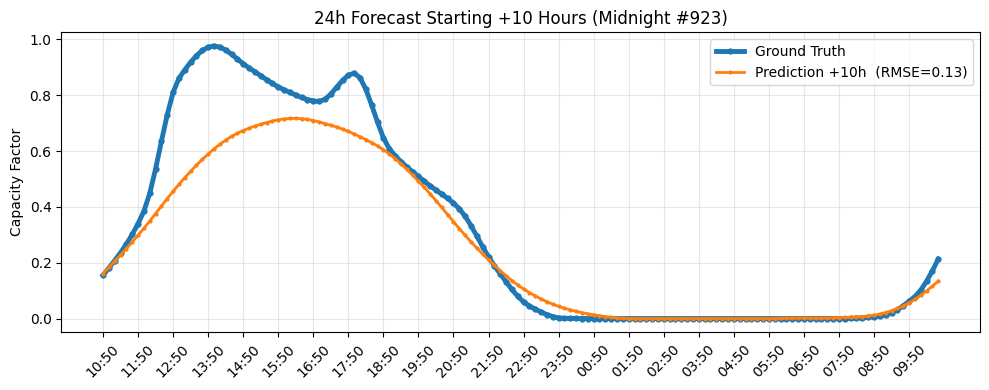

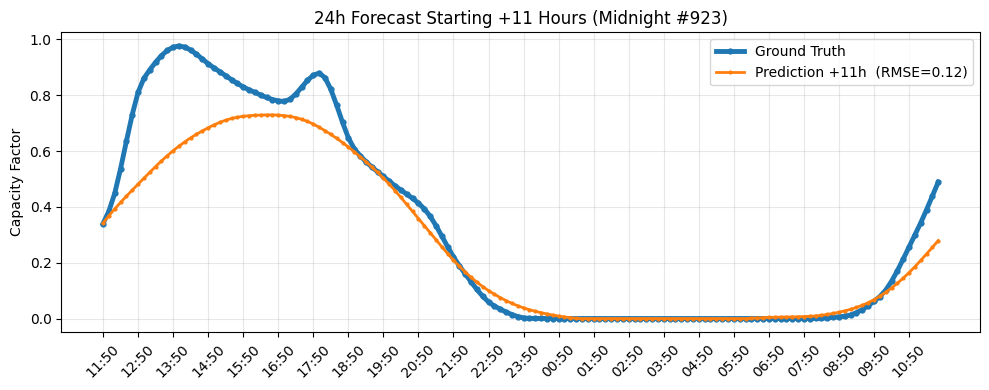

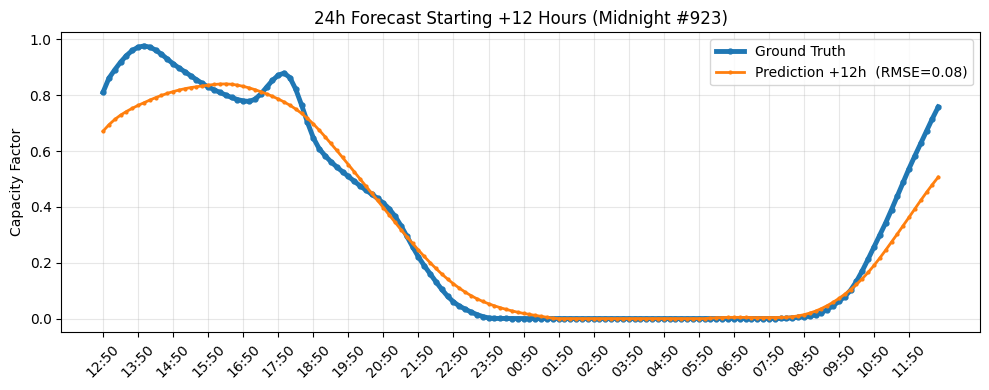

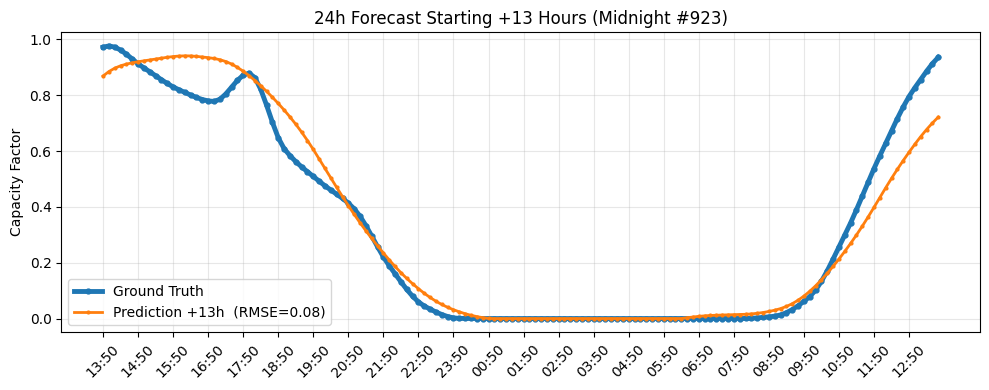

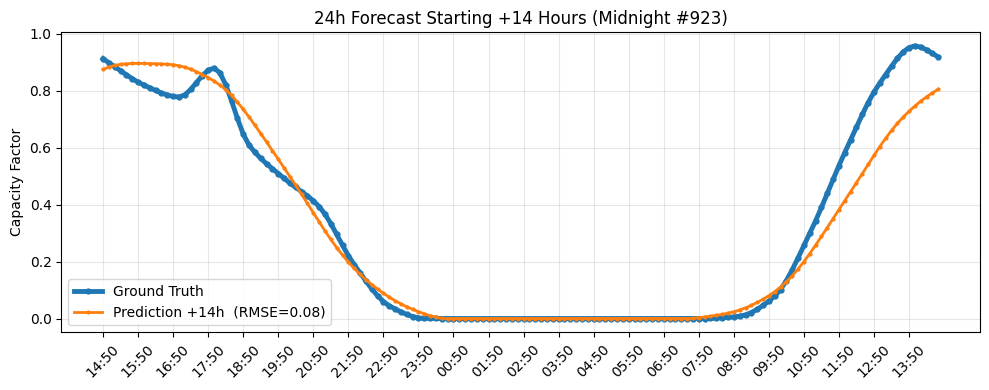

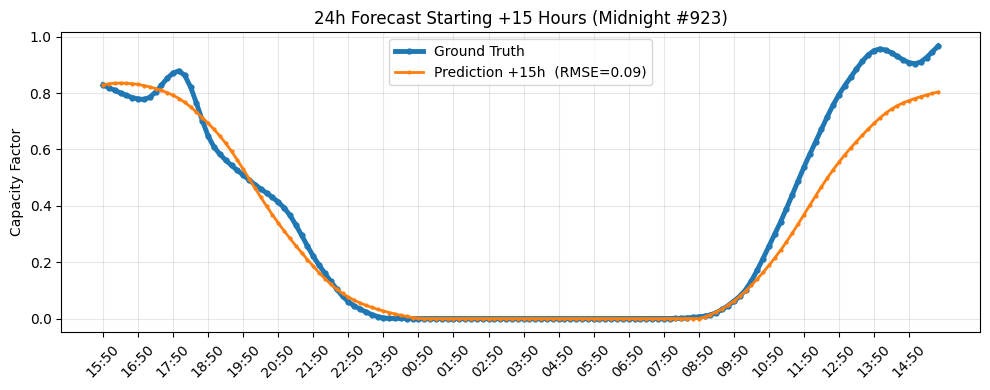

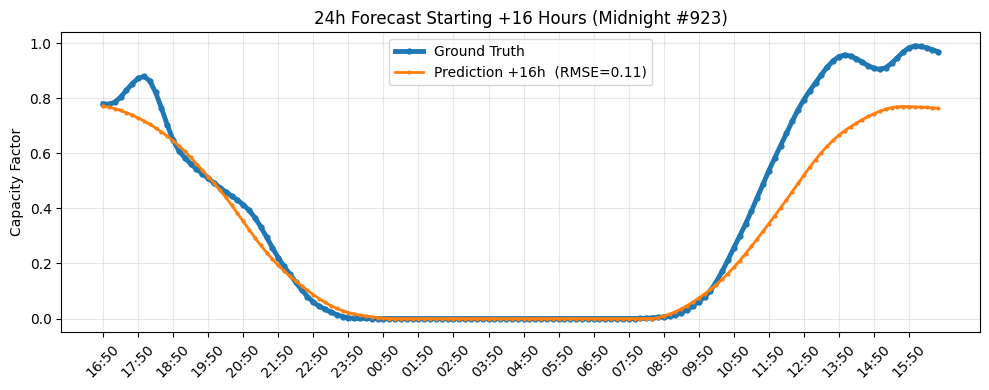

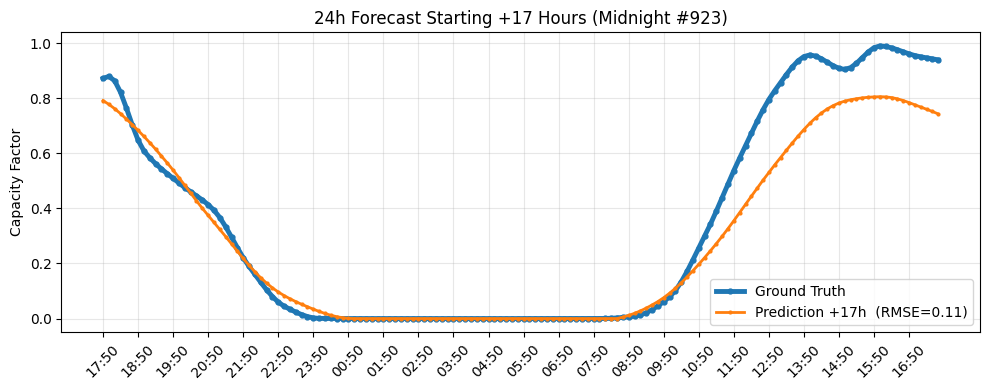

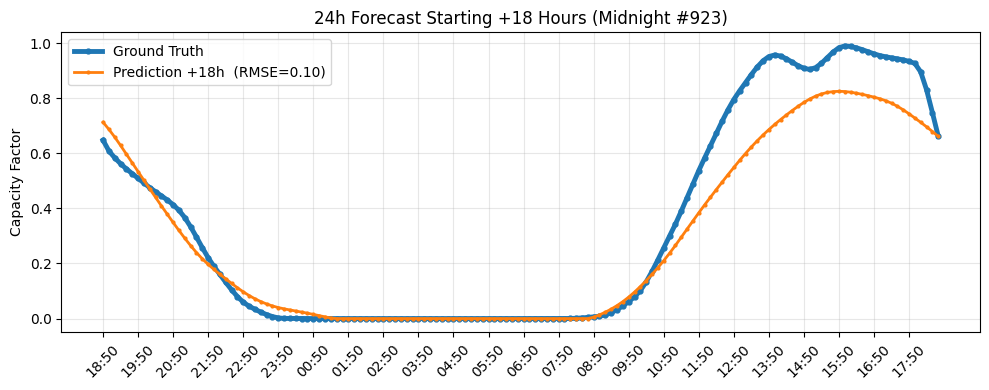

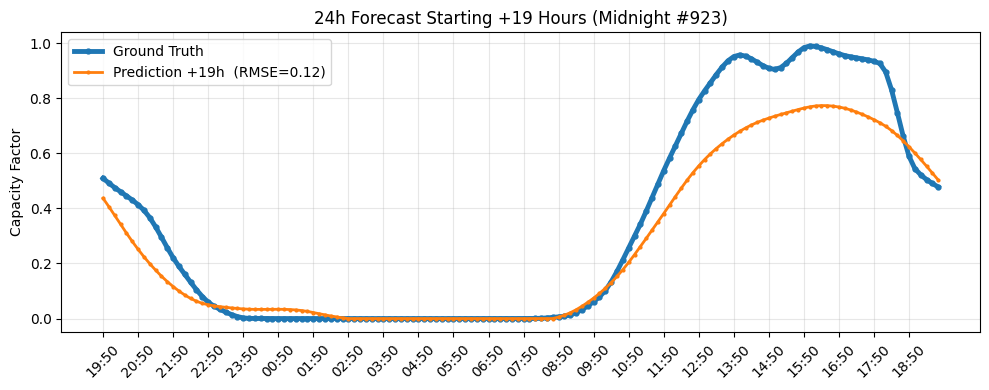

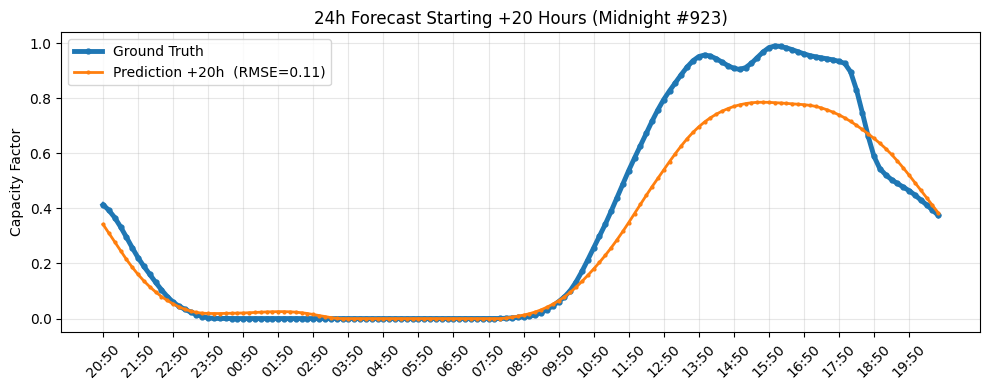

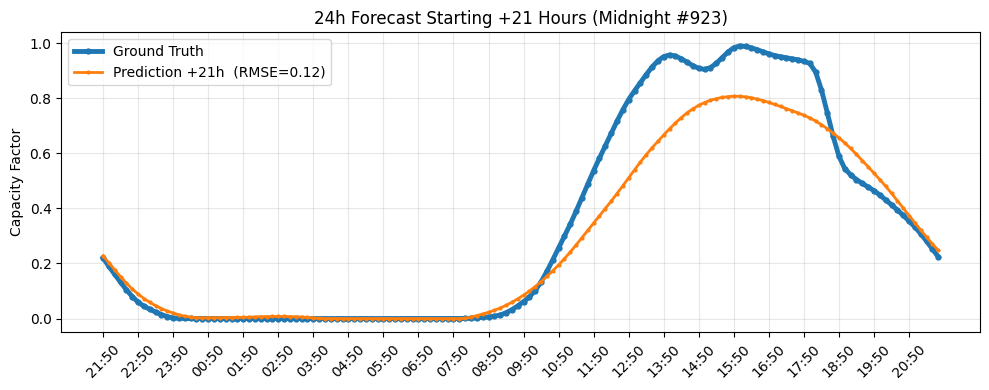

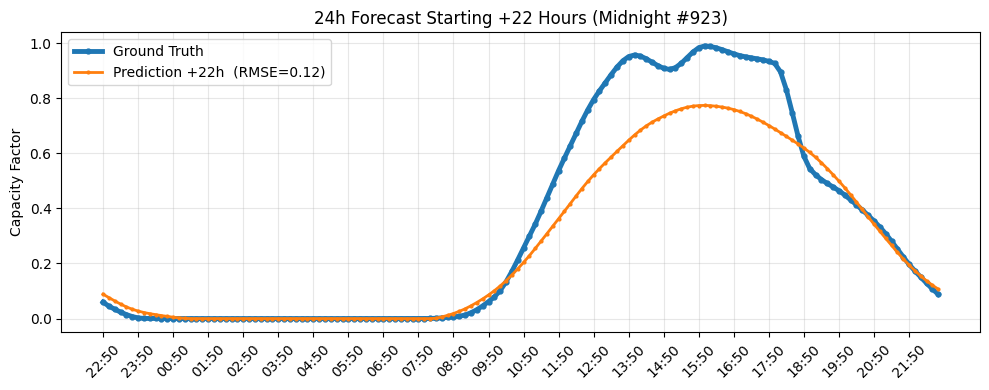

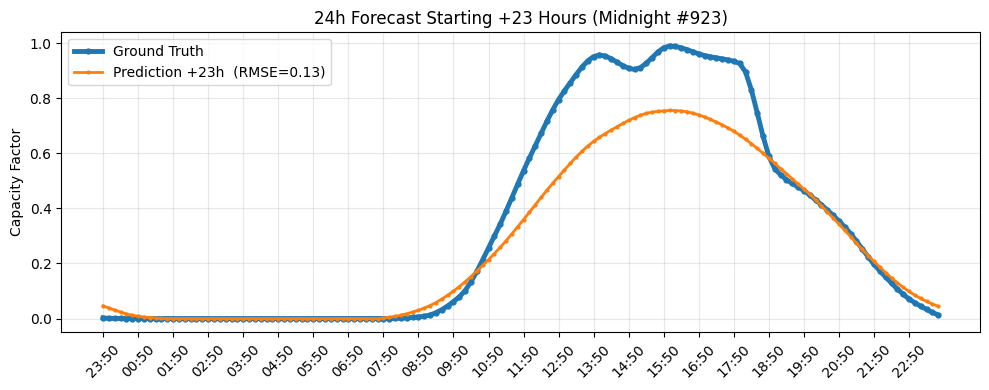

In [ ]:
from torch import mode


lstm = loaded_models["LSTM"]
gru = loaded_models["GRU"]
transformer = loaded_models["Transformer"]
tcn = loaded_models["TCN"]

sliding_48h_forecast_with_individual_plots(
    transformer,
    df_clean,
    hist_feats,
    fcst_feats,
    base_config,
    midnight_index=None,
    model_string="MultiChannel"
)

In [81]:
# === BASE EXPERIMENT CONFIG (low, PV, 24h, TE) ===

config2 = {
    "past_hours": 24,
    "future_hours": 24,
    "use_pv": True,
    "use_hist_weather": True,
    "use_forecast": True,
    "use_ideal_nwp": False,
    "use_time_encoding": True,
    "model_complexity": "low",
    "model_params": {
        "d_model": 32,
        "hidden_dim": 16,
        "num_heads": 2,
        "num_layers": 1,
        "dropout": 0.1,
        "tcn_channels": [16, 32],
        "kernel_size": 3,
    }
}
df_clean, hist_feats, fcst_feats, sh, sf, st, no_hist_power = \
    preprocess_features(df_raw.copy(), config2)

print("Hist feats:", hist_feats)
print("Fcst feats:", fcst_feats)
print("Rows:", len(df_clean))


hist_dim = len(hist_feats)
fcst_dim = len(fcst_feats) if fcst_feats else 0

print("hist_dim =", hist_dim)
print("fcst_dim =", fcst_dim)

mp = config2.copy()

mp["future_hours"] = config2["future_hours"]
mp["past_hours"]   = config2["past_hours"]
mp["use_forecast"] = config2.get("use_forecast", False)
mp["use_time_encoding"] = config2.get("use_time_encoding", True)
mp["te_dim"]       = config2.get("te_dim",8)

print(mp)


Hist feats: ['Capacity_Factor_hist', 'month_cos', 'month_sin', 'hour_cos', 'hour_sin', 'daypos_cos', 'daypos_sin', 'hourpos_sin', 'hourpos_cos']
Fcst feats: ['month_cos', 'month_sin', 'hour_cos', 'hour_sin', 'daypos_cos', 'daypos_sin', 'hourpos_sin', 'hourpos_cos']
Rows: 144145
hist_dim = 9
fcst_dim = 8
{'past_hours': 24, 'future_hours': 24, 'use_pv': True, 'use_hist_weather': True, 'use_forecast': True, 'use_ideal_nwp': False, 'use_time_encoding': True, 'model_complexity': 'low', 'model_params': {'d_model': 32, 'hidden_dim': 16, 'num_heads': 2, 'num_layers': 1, 'dropout': 0.1, 'tcn_channels': [16, 32], 'kernel_size': 3}, 'te_dim': 8}


In [ ]:
model_paths = {
    "LSTM": "/Users/jacobfernandez/Desktop/Research/FA2025/SolarPrediction/pt/LSTM/best_model_LSTM_low_PV+NWP_24h_TE.pt"     # "MultiChannelLSTM": "pt/MultiChannelLSTM/best_model_MultiChannelLSTM_low_PV_24h_TE.pt",
}
loaded_models2 = {}

print(f"\n=== Loading FAKETCN ===")

model = build_model("LSTM", hist_dim, fcst_dim, config2)
model = load_checkpoint(model, path)

loaded_models[model_name] = model
print(f"{model_name} loaded successfully.")




=== Loading FAKETCN ===


/Users/jacobfernandez/Desktop/Research/FA2025/SolarPrediction/venv/lib/python3.13/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


RuntimeError: Error(s) in loading state_dict for LSTM:
	Missing key(s) in state_dict: "hist_proj.weight", "hist_proj.bias", "lstm.weight_ih_l0", "lstm.weight_hh_l0", "lstm.bias_ih_l0", "lstm.bias_hh_l0". 
	Unexpected key(s) in state_dict: "encoder.0.conv1.weight", "encoder.0.conv1.bias", "encoder.0.conv2.weight", "encoder.0.conv2.bias", "encoder.0.net.0.weight", "encoder.0.net.0.bias", "encoder.0.net.4.weight", "encoder.0.net.4.bias", "encoder.0.downsample.weight", "encoder.0.downsample.bias", "encoder.1.conv1.weight", "encoder.1.conv1.bias", "encoder.1.conv2.weight", "encoder.1.conv2.bias", "encoder.1.net.0.weight", "encoder.1.net.0.bias", "encoder.1.net.4.weight", "encoder.1.net.4.bias", "encoder.1.downsample.weight", "encoder.1.downsample.bias", "encoder.2.conv1.weight", "encoder.2.conv1.bias", "encoder.2.conv2.weight", "encoder.2.conv2.bias", "encoder.2.net.0.weight", "encoder.2.net.0.bias", "encoder.2.net.4.weight", "encoder.2.net.4.bias", "encoder.2.downsample.weight", "encoder.2

In [62]:
faketcn = model
# gru = loaded_models["GRU"]
# transformer = loaded_models["Transformer"]
# tcn = loaded_models["TCN"]

sliding_48h_forecast_with_individual_plots(
    faketcn,


    df_clean,
    hist_feats,
    fcst_feats,
    base_config,
    midnight_index=935,
    model_string="TCN"
)

[INFO] Midnight sample #935 → df index 127589
[INFO] Timestamp = 2022-06-05 00:50:00


RuntimeError: Given groups=1, weight of size [16, 9, 3], expected input[1, 144, 9] to have 9 channels, but got 144 channels instead